In [65]:
import bs4
import matplotlib.pyplot as plt
from selenium import webdriver
import selenium
from selenium.webdriver.chrome.options import Options
import time
import re
import html
import statistics

Uporabili bomo knjižico Selenium, saj requests modul ni deloval zaradi IMDb-jeve zaščite

In [66]:
options = Options()
options.add_argument("--disable-blink-features=AutomationControlled") # brez tega je spletna stran prepoznala webdriver kot robota
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36") # user agent pove od kot izvira request 
# (Windows-based Crome v našem primeru)
options.add_argument("--headless") # ne pokaže brksalnika pri pridobivanju podatkov


Uporabili bomo modul Beautiful Soup, da lahko lepše analiziramo podatke. Ti podatki bodo vedno posodobljeni, saj se bodo s posodobitvijo spletne strani posodobili tudi naši podatki.

In [67]:
def preveri_st_filmov(url):
    driver = webdriver.Chrome(options=options)
    driver.get(url)
    time.sleep(27) # da se stran naloži in da ne naredimo preveč requestov naenkrat (tudi proti zaznavanju robotov)
    piskoti = driver.find_element(selenium.webdriver.common.by.By.XPATH, "//html/body/div[2]/div[2]/div/div[2]/div/button[2]") # XPATH dobimo z inspekcijo spletne strani
    piskoti.click()
    
    vsebina = bs4.BeautifulSoup(driver.page_source, 'html.parser') # prebere HTML vsebino
    filmi = vsebina.find("ul", class_="ipc-metadata-list") # vsi filmi so zhrannjeji v znackah <ul class=ipc-metadata-list><\ul>
    
    seznam_filmov = filmi.find_all(class_="ipc-metadata-list-summary-item")
    driver.quit()
    return seznam_filmov, len(seznam_filmov)


In [68]:
def iskanje_filmov(zacetno_leto_iskanja, koncno_leto_iskanja, velikost_vzorca, izbrani_zanri):   
    # link do naprednega iskanja filmov (analizirali bomo le filme). Parameter count predstavlja velikost podatkov
    # https://www.imdb.com/search/title/?title_type=feature&genres=action&count=250
    # podatki za zanr bodo oblike https://www.imdb.com/search/title/?title_type=feature&genres=zanr1,zanr2,...
    seznam_moznih_zanrov = ['action', 'adventure', 'animation', 'biography', 'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy', 'film-noir', 'game-show', 'history', 'horror', 'music', 'musical', 'mystery', 'news', 'reality-tv', 'romance', 'sci-fi', 'sport', 'talk-show', 'thriller', 'war', 'western']
        
    veljaven_izbor = False 
    najdeni_filmi = []

    # preveri ali je izbor zanra veljaven (pustil v kodi, če se odločim, da bi jo kdaj predelal na user-input-based), za zdaj so vsi izbrani seznami veljavni
    while not veljaven_izbor:
        izbrani_zanri.rstrip() # da se izognemo nepotrebnim presledkom na koncu vrstice
        izbrani_zanri = izbrani_zanri.split(",")
        izbrani_zanri = [x.lower() for x in izbrani_zanri]

        if set(izbrani_zanri).issubset(seznam_moznih_zanrov): # ali je seznam podseznam seznama moznih zanrov
            veljaven_izbor = True
            url_izbor = ",".join(izbrani_zanri)
            nov_url = f"https://www.imdb.com/search/title/?title_type=feature&release_date={zacetno_leto_iskanja}-01-01,{koncno_leto_iskanja}-12-31&genres={url_izbor}&count={velikost_vzorca}"
            # rabimo preveriti ali je izbor preozek ali ne
            filmi, st_filmov = preveri_st_filmov(nov_url)
            if st_filmov > 0:
                najdeni_filmi.extend(filmi)
            elif st_filmov == 0:
                print("Izbran nabor je preozek. Poskusi izbrati širši izbor")
                veljaven_izbor = False
            
        else:
            print("To ni veljaven izbor vrste filmov.")
        
        
        return najdeni_filmi, zacetno_leto_iskanja, koncno_leto_iskanja
    # zdaj imamo veljaven nabor žanrov, po kateri lahko naredimo analizo podatkov


Zdaj, ko imamo podakte o filmih, moramo shraniti te podatke v .txt datoteke (naslov, dolžina, leto izdaje, ocena, ...)

In [69]:
#funkcija, ki zapise podatke v datoteko

def zapisi_podatke(zac_leto, kon_leto, velikost_vzorca, vrsta_filmov):
    nas_seznam_filmov, zac_leto, kon_leto = iskanje_filmov(zac_leto, kon_leto, velikost_vzorca, vrsta_filmov)  
    podatki_o_filmih = []
    ime_datoteke =  f"Filmi_{vrsta_filmov}_{zac_leto}-{kon_leto}.txt"
    
    for film in nas_seznam_filmov:
        neobdelan_naslov = re.findall(r'<h4 class="ipc-title__text">(.+?)</h4>', film.decode_contents())[0] # (.+?) pomeni katerikoli znak in ena ali več pojavitev. ? sem uporabil, ker
        # se je včasih zgodilo da je re.findall vzel predolg string
        naslov = html.unescape(re.sub(r"\d+. ", "", neobdelan_naslov)) # uporabil sem html.unescape ker sem v rezultatih pri naslovih namesto znaka & dobil &amp;
        dodatni_podatki = re.findall(r'<li class="ipc-inline-list__item" role="presentation">(.+?)</li>', film.decode_contents())
        
        # problem je, da nekateri filmi še nimajo določene dolžine
        leto_izida = dodatni_podatki[0]
        try:
            neobdelano_trajanje = re.findall(r"\d+", dodatni_podatki[1])
            try:
                trajanje = int(neobdelano_trajanje[0]) * 60 + int(neobdelano_trajanje[1]) # h * 60 + min
            except IndexError:
                trajanje = int(neobdelano_trajanje[0]) # če imamo samo 1 element imamo samo minute
        except IndexError:
            trajanje = "N/A"
        
        # filmi, ki še niso bili izdani še nimajo ocene
        try:
            ocena = re.findall(r'<span class="ipc-rating-star--rating">(.+?)</span>', film.decode_contents())[0]
        except IndexError:
            ocena = "NE"

        podatki_o_filmih.append([naslov, leto_izida, trajanje, ocena])
    with open(ime_datoteke, "w", encoding="utf-8") as file:
        file.write(f"naslov% leto_izida% trajanje% ocena\n") # uporabil sem %, ker so nekateri filmi v naslovu imeli , ali pa ;
        for podatek in podatki_o_filmih:
            file.write(f"{podatek[0]}% {podatek[1]}% {podatek[2]}% {podatek[3]}\n")
  
        

Sestavili smo funkcije, ki bodo obdelale podatke. Zdaj nam ostane samo predstavitev podatkov. Izbral bom več časovnih obdobij (1980-1989, 1990-1999, 2000-2009, 2010-2019, 2020-2026) in filme iz različnih žanrov.

In [ ]:
dvojice_letnic = [(1980, 1989), (1990, 1999), (2000, 2009), (2010, 2019), (2020, 2026)] # se lahko spremeni, če bi želeli analizirati druge podatke (npr. starejše filme)

"""
for i in dvojice_letnic:
    z_l = i[0]
    k_l = i[1]
    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="action")
    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="animation")
    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="family")
    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="comedy")
    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="romance")
    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="horror")
    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="drama")
"""
    
# funkcija je zakomentirana, ker je že bila uporabljena


'\nfor i in dvojice_letnic:\n    z_l = i[0]\n    k_l = i[1]\n    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="action")\n    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="animation")\n    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="family")\n    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="comedy")\n    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="romance")\n    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="horror")\n    zapisi_podatke(zac_leto=z_l, kon_leto=k_l, velikost_vzorca=250, vrsta_filmov="drama")\n'

Pridobili smo vse podatke. Vsi so zapisani v .txt datoteki in zdaj jih lahko analiziramo.

In [71]:
def ime_izid_trajanje_ocena(datoteka):
    seznam_imen = []
    seznam_ocen = []
    seznam_izidov = []
    seznam_trajanj = []
    with open(datoteka, "r", encoding="utf-8") as datoteka:
        podatki = datoteka.readlines()
    
    for vrstica in podatki[1:]:
        vrstica = vrstica.strip()
        
        if not vrstica:
            continue # preskočimo prazne vrstice
        x = [kos.strip() for kos in vrstica.split("%")] # ker so podatki oblike: "presledek"podatek
    
        ime = x[0]
        leto = x[1]
        trajanje = x[2]
        ocena = x[3]

        if ocena.upper() == "NE":
            continue
        if not leto.isdigit():
            continue
        if not trajanje.isdigit():
            continue
            
        # preverimo ali je ocena številka, če ni filma ne dodamo na sezanm
        try:
            x[3] = re.sub(r'\n', '', x[3])
            seznam_imen.append(ime)
            seznam_ocen.append(float(x[3]))
            seznam_izidov.append(int(x[1]))
            seznam_trajanj.append(int(x[2]))
        except ValueError:
            continue
        
    
    return seznam_imen, seznam_izidov, seznam_trajanj, seznam_ocen   

  
   

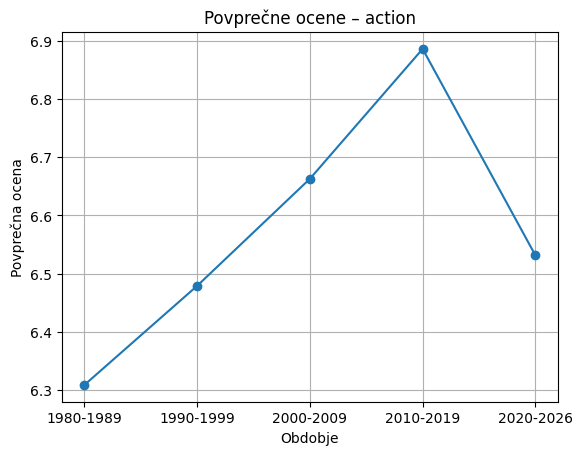

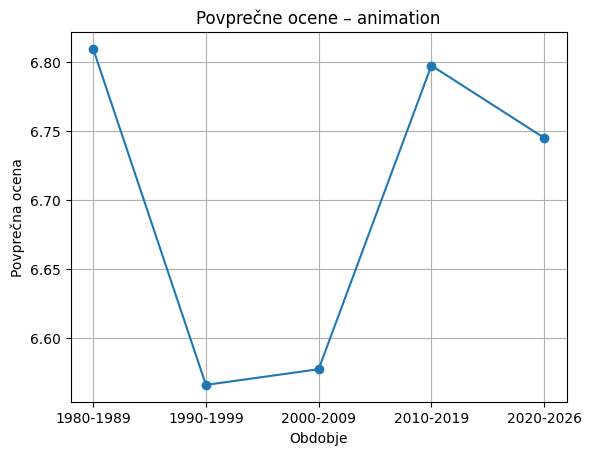

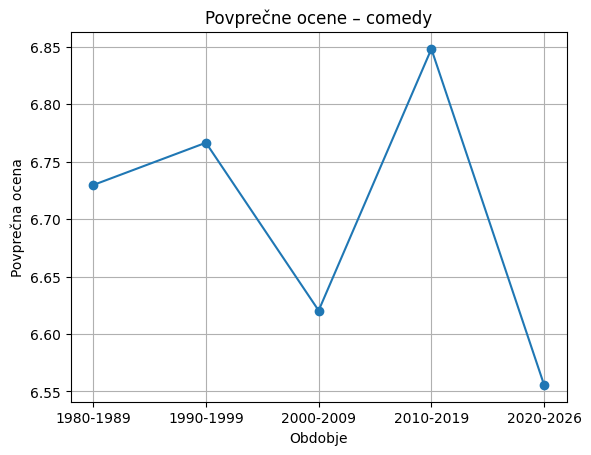

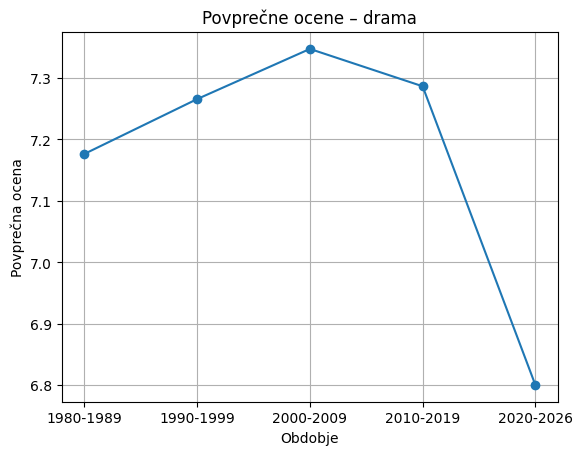

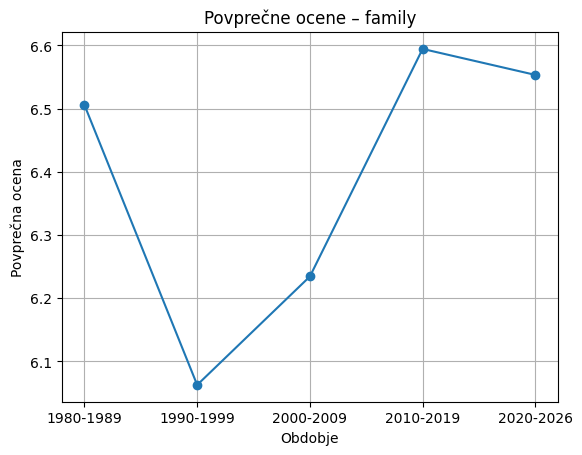

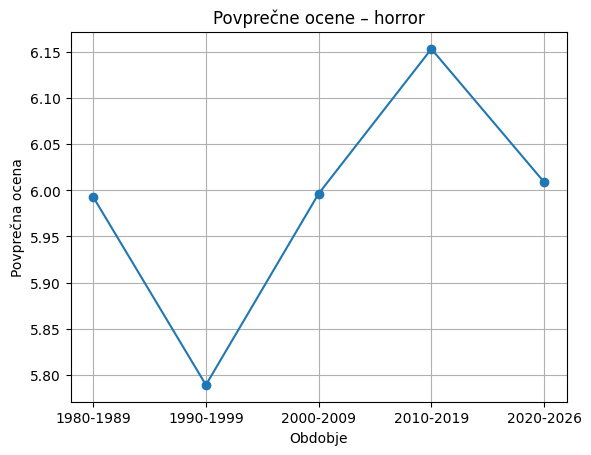

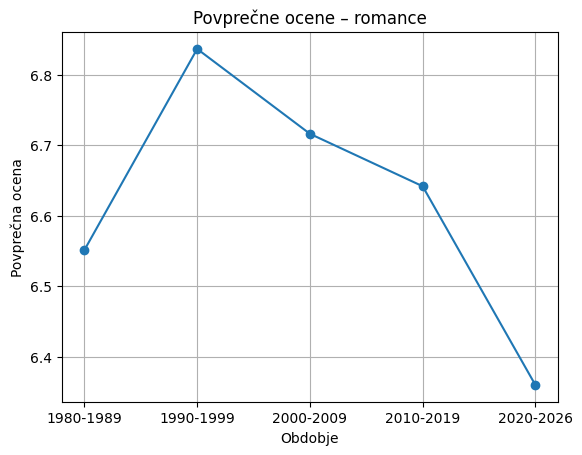

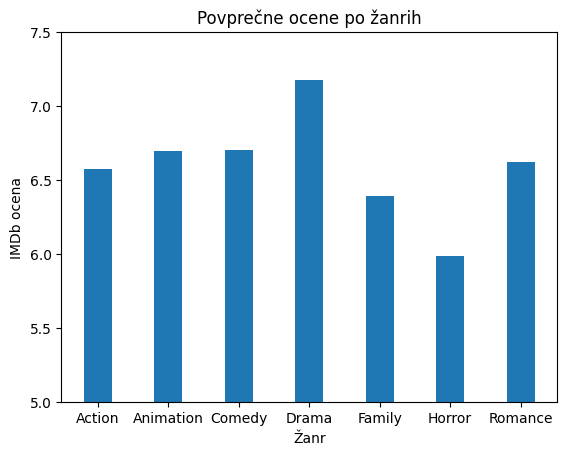

In [ ]:
"""
# če bi želeli, da je funkcija user input
zbrane_vrste_filmov = []
while True:
    f = input("Prosim vpiši kakšne vrste filmov bi rad analiziral v obliki
    žanr1,žanr2,... Napiši E, da končaš vpisovanje.")
    f.rstrip()
    if f.lower() == "e":
        break
    else:
        zbrane_vrste_filmov.append(f)
    
"""

zbrane_vrste_filmov = ["action", "animation", "comedy", "drama", "family", "horror", "romance"]
ocene_filmov = []
# povprečne ocene
for vrsta in zbrane_vrste_filmov:
    povprecne_ocene = []
    obdobja = []
    for k in dvojice_letnic:
        z_l = k[0]
        k_l = k[1]
        obdobje_string = f"{z_l}-{k_l}"
        a, b, c, d = ime_izid_trajanje_ocena(f"Filmi_{vrsta}_{z_l}-{k_l}.txt")
        povprecne_ocene.append(statistics.mean(d))
        obdobja.append(obdobje_string)

    plt.plot(obdobja, povprecne_ocene, marker="o") # marker="o" pomeni, da imamo pri točkah piko 
    plt.title(f"Povprečne ocene – {vrsta}")
    plt.xlabel("Obdobje")
    plt.ylabel("Povprečna ocena")
    plt.grid(True)
    plt.show()
    ocene_filmov.append(statistics.mean(povprecne_ocene))

# povprečje od 1980-2026 glede na žanr
plt.bar([z.title() for z in zbrane_vrste_filmov ], ocene_filmov, width=0.4)
plt.ylim(5, 7.5) # da so razlike med ocenami žanrov večje
plt.title("Povprečne ocene po žanrih")
plt.xlabel("Žanr")
plt.ylabel("IMDb ocena")
plt.show()

Vidimo, da so drame s povprečno oceno 7.18 najvišje ocenjen žanr, medtem ko grozljivke z oceno 5.99 prejemajo najslabše ocene, kar prikazuje zadnji graf. Iz grafov lahko tudi razberemo, da so bili pri večini žanrov (razen pri romantičnih filmih in dramah) najbolje ocenjeni filmi posneti v obdobju 2010–2019. Romantični filmi pa dobivajo čedalje slabše ocene že od obdobja 1990–1999 naprej.

Pogledali si bomo, ali je ocena filma povezana z njegovo dolžino.

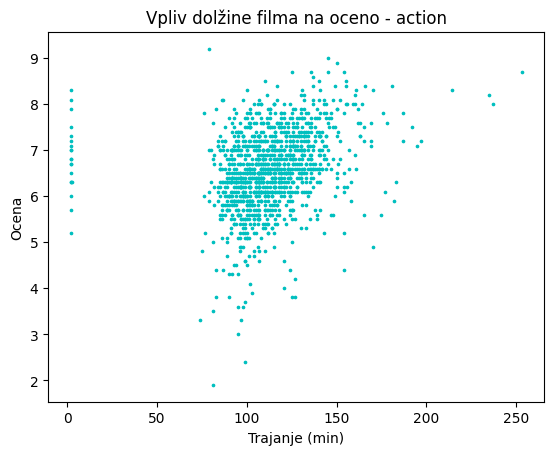

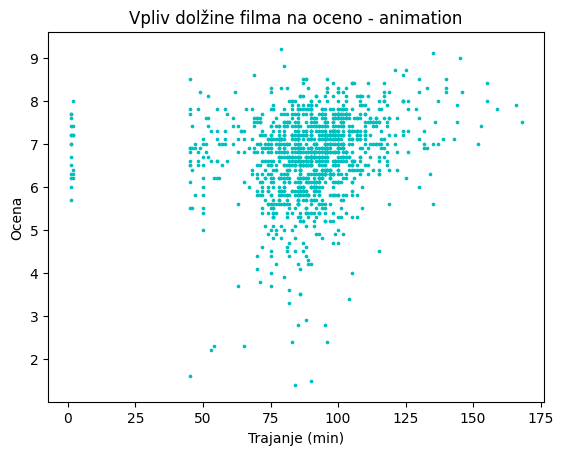

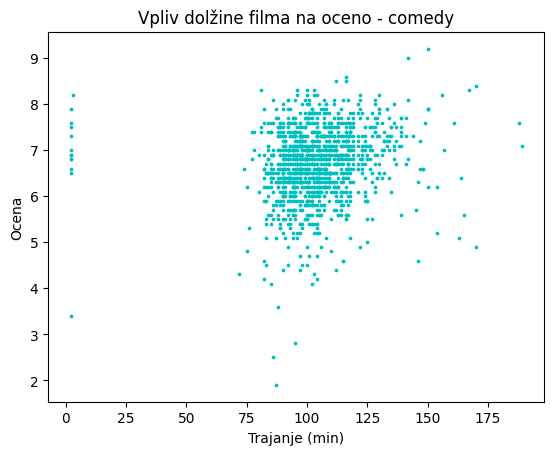

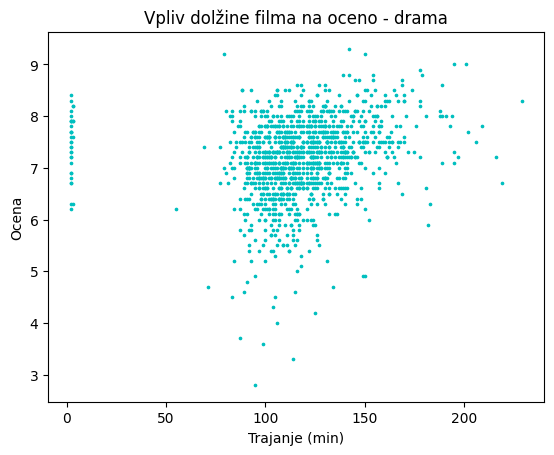

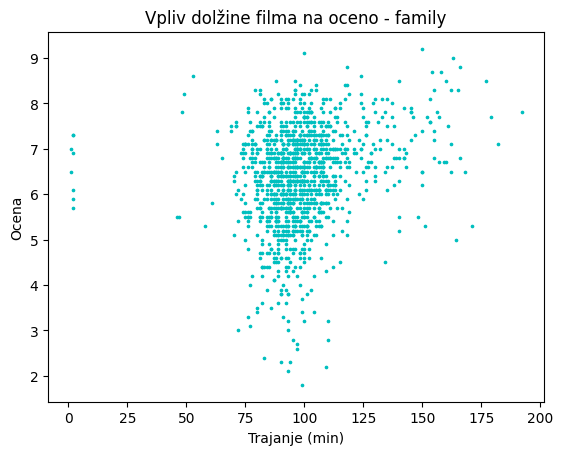

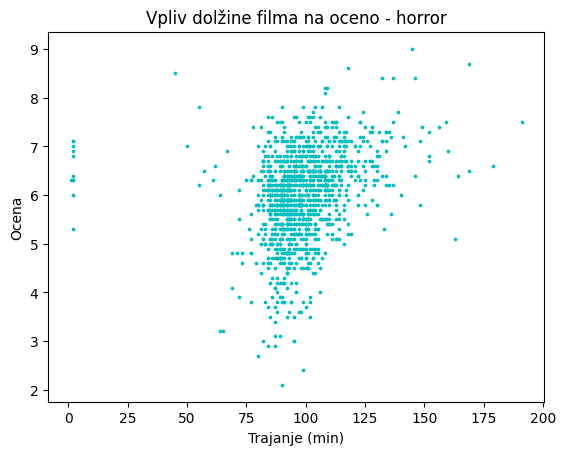

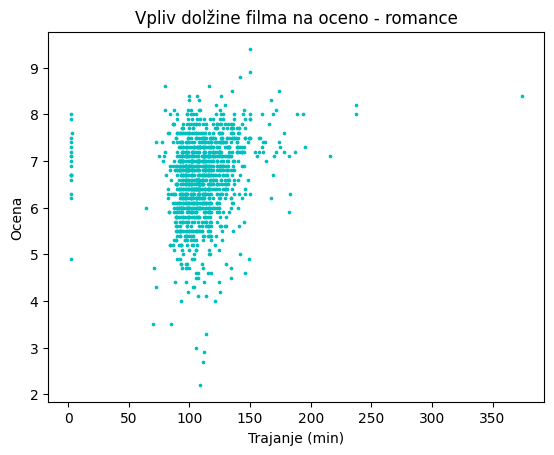

In [73]:
# trajanje in ocene
for vrsta in zbrane_vrste_filmov:
    ocene = []
    trajanje = []
    for k in dvojice_letnic:
        z_l = k[0]
        k_l = k[1]
        a, b, c, d = ime_izid_trajanje_ocena(f"Filmi_{vrsta}_{z_l}-{k_l}.txt")
        ocene.extend(d)
        trajanje.extend(c)
    
    plt.scatter(trajanje, ocene, s=2.7, c="c") # parameter s nastavi velikost pik, parameter c pa nastavi barvo
    plt.title(f"Vpliv dolžine filma na oceno - {vrsta}")
    plt.xlabel("Trajanje (min)")
    plt.ylabel("Ocena")
    
    plt.show()

Kot vidimo dolžina filma ne vpliva na oceno, ki jo film dobi. Krajši filmi dobijo enake, včasih celo boljše ocene, kot pa daljši filmi. Filmi, ki imajo dolžino blizu 0 niso napake, ampak kratki dodatki k daljšim filmom (npr. Holiday Special). Poglejmo še, ali filmi postajajo daljši, krajši ali pa se njihova dolžina v povprečju ni spremenila.

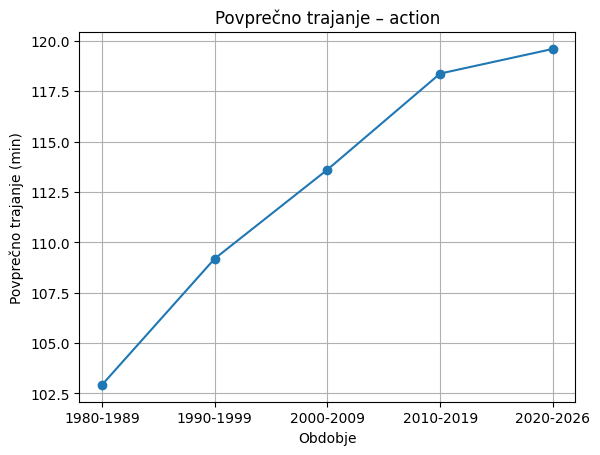

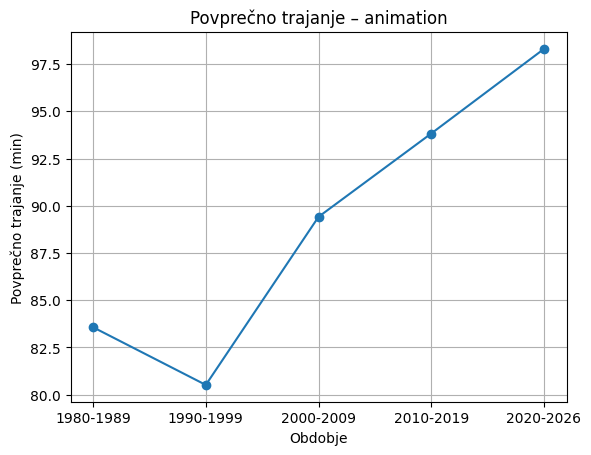

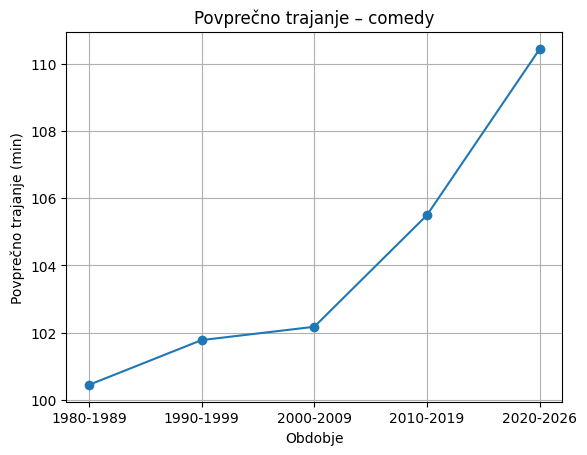

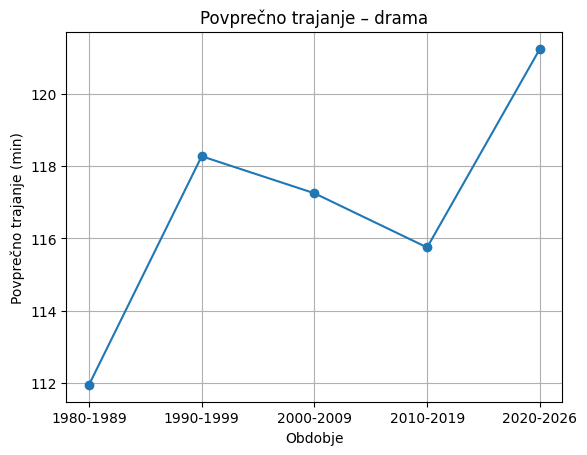

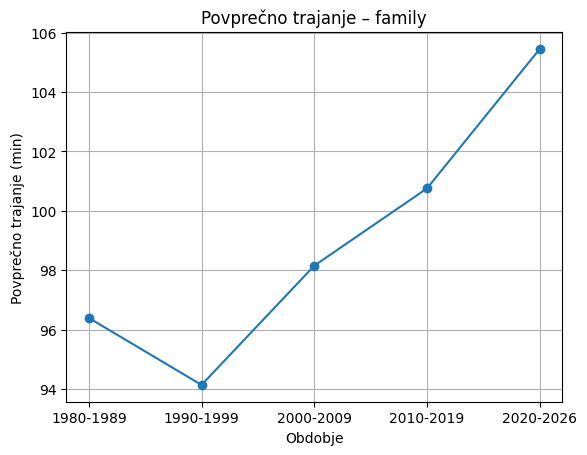

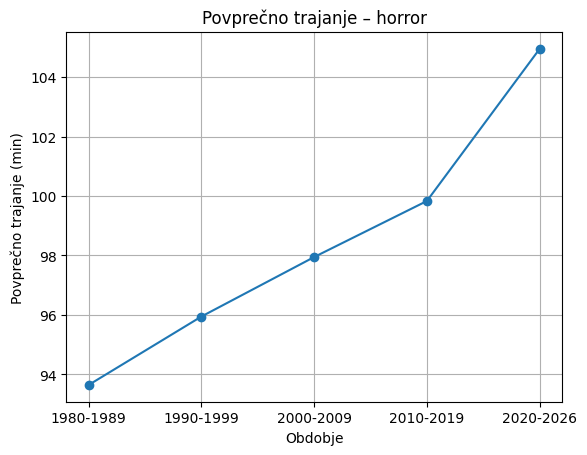

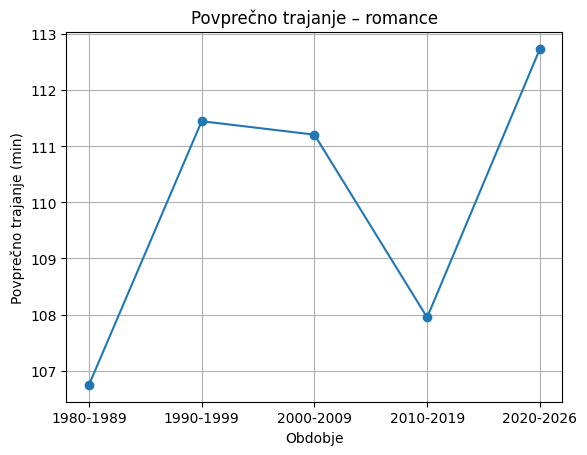

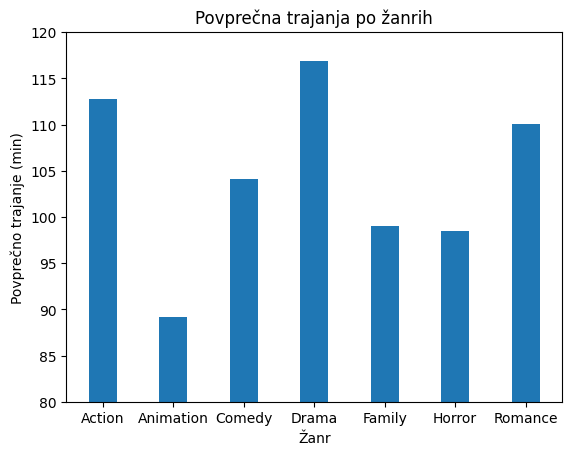

In [74]:
trajanja_filmov = []
# 
for vrsta in zbrane_vrste_filmov:
    povprecno_trajanje = []
    obdobja = []
    for k in dvojice_letnic:
        z_l = k[0]
        k_l = k[1]
        obdobje_string = f"{z_l}-{k_l}"
        a, b, c, d = ime_izid_trajanje_ocena(f"Filmi_{vrsta}_{z_l}-{k_l}.txt")
        povprecno_trajanje.append(statistics.mean(c))
        obdobja.append(obdobje_string)

    plt.plot(obdobja, povprecno_trajanje, marker="o")
    plt.title(f"Povprečno trajanje – {vrsta}")
    plt.xlabel("Obdobje")
    plt.ylabel("Povprečno trajanje (min)")
    plt.grid(True)
    plt.show()
    trajanja_filmov.append(statistics.mean(povprecno_trajanje))

# povprečje od 1980-2026 glede na žanr
plt.bar([z.title() for z in zbrane_vrste_filmov], trajanja_filmov, width=0.4)
plt.ylim(80, 120)
plt.title("Povprečna trajanja po žanrih")
plt.xlabel("Žanr")
plt.ylabel("Povprečno trajanje (min)")
plt.show()

Od leta 1980 se je povprečna dolžina filma pri vseh žanrih povečala za približno 10 minut. Animacijski filmi so v povprečju najkrajši, kar je pričakovano, saj so namenjeni otrokom, medtem ko so drame v povprečju najdaljši filmi.